# iEMG vs sEMG

Using the sEMG -> we test the performance

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import scipy, os
from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys

from sklearn.model_selection import learning_curve

sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info

import warnings
warnings.filterwarnings('ignore')


def restore_labels(mat, labels_windowed):

    original_length = mat['Data_ADC'].shape[1]
    win_size = 2000 # 200ms 10
    win_step = 100
    #valid_length = original_length - 2 * 60

    label_full = np.zeros(original_length, dtype=labels_windowed.dtype) # 복원될 시계열 레이블 (원본 길이)

    # 슬라이딩 윈도우 인덱스 따라 레이블 채워넣기
    for i, label in enumerate(labels_windowed):
        start = 60 + i * win_step
        end = start + win_size
        if end <= original_length - 60:
            label_full[start:end] = label

    return label_full


def filtering_zero(X, y, erase_label):
    # 1. erase_label 제거
    keep_indices = y != erase_label
    X = X[keep_indices]
    y = y[keep_indices]

    # 2. erase_label보다 큰 값은 1씩 감소
    y = np.where(y > erase_label, y - 1, y)

    return X, y

def vis_graph(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.legend()
    plt.show()

def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    return cm


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [2]:
def return_X_y(path, num_session, balance):
    fs, lower_cutoff, upper_cutoff = Feature_info.fs, Feature_info.lower_cutoff, Feature_info.upper_cutoff
    # fs, lower_cutoff, upper_cutoff = Feature_info.fs, 1, 300
    filter_b, filter_a = Same_with_MATLAB.cheby2(4, 30, [lower_cutoff / (fs/2), upper_cutoff / (fs/2)], btype='bandpass')

    data_per_class_files = os.listdir(path)
    X, y = [], []

    for f in num_session:
        for cls in data_per_class_files:
            input_path = path+cls+'/'
            files = os.listdir(input_path)
            mat = scipy.io.loadmat(input_path+files[f])
            label = mat['Data_Cls'].reshape(-1)  # shape: (1, 1729)

            feat_mean = np.tile(Feature_info.feat_mean_lst, (4, 1))
            feat_std = np.tile(Feature_info.feat_std_lst, (4, 1))

            mapped_label = np.where(label == 0, 0, int(cls))
            restored_label = restore_labels(mat, mapped_label)

            #print(mat['Data_ADC'].shape, mat['Data_Cls'].shape, restored_label.shape)
            extractor = Same_with_MATLAB.EMGFeatureExtractor(feat_mean, feat_std, filter_b, filter_a, Norm_bool=False, num_feature_set=14) #I tried 23, but not so good
            extractor.buffer = mat['Data_ADC']
            #1000, 50 = winsize and winstep
            features, labels = extractor.extract_features_with_labels(win_size=2000, win_step=100, feat_exclude=25, filtering=False, restored_label=restored_label)

            features = np.transpose(features, (2, 0, 1))  # shape: (1729, 4, 14)
            X.append(features)
            y.append(labels)
            #print(features.shape, labels.shape)

    X_train = np.concatenate(X, axis=0)
    y_train = np.concatenate(y, axis=0)
    X_train = X_train[:, :, :, np.newaxis]
    #print(pd.Series(y_train).value_counts())
    print(X_train.shape, y_train.shape)

    if balance:
        X_train, y_train = balance_data(X_train, y_train)

    return X_train, y_train


def return_X_y_get_from_matfile(path, num_session, balance):
    data_per_class_files = os.listdir(path)
    X, y = [], []

    for f in num_session:
        for cls in data_per_class_files:
            input_path = path+cls+'/'
            files = os.listdir(input_path)
            mat = scipy.io.loadmat(input_path+files[f])
            labels = mat['Data_Cls'].reshape(-1)  # shape: (1, 1729)

            features = mat['Data_Fea']
            features = np.transpose(features, (2, 0, 1))  # shape: (1729, 4, 14)
            X.append(features)
            y.append(labels)

    X_train = np.concatenate(X, axis=0)
    y_train = np.concatenate(y, axis=0)
    X_train = X_train[:, :, :, np.newaxis]
    #print(pd.Series(y_train).value_counts())
    print(X_train.shape, y_train.shape)

    if balance:
        X_train, y_train = balance_data(X_train, y_train)

    return X_train, y_train



def train_model_feature_wise(X_train, y_train, X_test, y_test):
    X_train, y_train = filtering_zero(X_train, y_train, erase_label=0)
    X_test, y_test = filtering_zero(X_test, y_test, erase_label=0)
    ACC_lst = []

    for feature_idx in [2, 10]:
        One_X_train = X_train[:, :, feature_idx, :]
        One_X_test = X_test[:, :, feature_idx, :]

        model = Model.Original_model_1DCNN(One_X_train.shape[1:], num_class=np.max(y_train)+1)

        history, model = Model.Train_model(
            model, One_X_train, y_train, One_X_test, y_test,
            set_epoch=200, set_batch_size=256, Model_name='V0',
            set_verbose=False, save_model_set=False
        )
        ACC_lst.append(np.max(history.history['val_accuracy']))
        #vis_graph(history)
        #print("\n\n")
        #heatmap_confusion_matrix(One_X_test, y_test, model)

def train_model(X_train, y_train, X_test, y_test, heatmap_bool=False, draw_learning_curve=False):
    X_train, y_train = filtering_zero(X_train, y_train, erase_label=0)
    X_test, y_test = filtering_zero(X_test, y_test, erase_label=0)

    model = Model.Original_model(X_train.shape[1:], num_class=np.max(y_train)+1)

    history, model = Model.Train_model(
        model, X_train, y_train, X_test, y_test,
        set_epoch=100, set_batch_size=256, Model_name='V0',
        set_verbose=False, save_model_set=False
    )
    if draw_learning_curve:
        vis_graph(history)

    if heatmap_bool:
        cm = heatmap_confusion_matrix(X_test, y_test, model)
        return cm
    return None

def run(subject):
    bluetooth_id = 'E9AD0E7DCC2B'

    X_train, y_train = return_X_y(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=[0,1,2,3], balance=True)
    X_test, y_test = return_X_y(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=[4], balance=True)
    #train_model(X_train, y_train, X_test, y_test, heatmap_bool=False)
    train_model_feature_wise(X_train, y_train, X_test, y_test)

In [3]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'

### 방금 Manual하게 feature extraction 을 써봤는데 그냥 원래 저장되어 있는 mat['Data_Fea'] 보다 한참 안좋음 - 코드에 문제 있는듯

In [4]:
def run(subject, Train_session, Test_session):
    bluetooth_id = 'E9AD0E7DCC2B'

    X_train, y_train = return_X_y_get_from_matfile(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=Train_session, balance=True)
    X_test, y_test = return_X_y_get_from_matfile(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=Test_session, balance=True)
    cm = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    return cm
    #train_model_feature_wise(X_train, y_train, X_test, y_test)

(34487, 4, 14, 1) (34487,)
(8613, 4, 14, 1) (8613,)
Start Training (total epochs: 100)...
Maximum training accuracy : 90.49%
Maximum validation accuracy : 90.32%


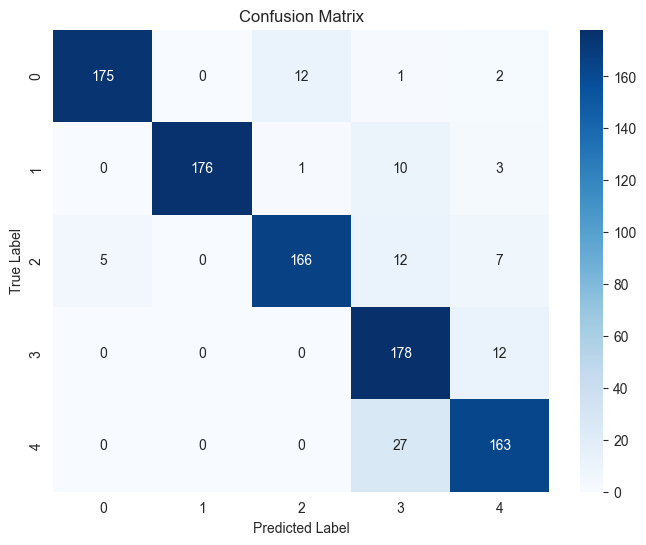

In [5]:
import importlib
importlib.reload(Model)
H = []

H_CM = run(subject='Byeongchan', Train_session=[0,1,2,3], Test_session=[4])
H.append(H_CM)
# Adam lr 0.1 = Maximum validation accuracy : 76%
# Adam lr 0.05 = Maximum validation accuracy : 77.94%
# Adam lr 0.01 = Maximum validation accuracy : 88.5%
# Adam lr 0.005 = Maximum validation accuracy : 88.6%
# Adam lr 0.001 = Maximum validation accuracy : 82.34%

(34475, 4, 14, 1) (34475,)
(8625, 4, 14, 1) (8625,)
Start Training (total epochs: 100)...
Maximum training accuracy : 90.31%
Maximum validation accuracy : 91.69%


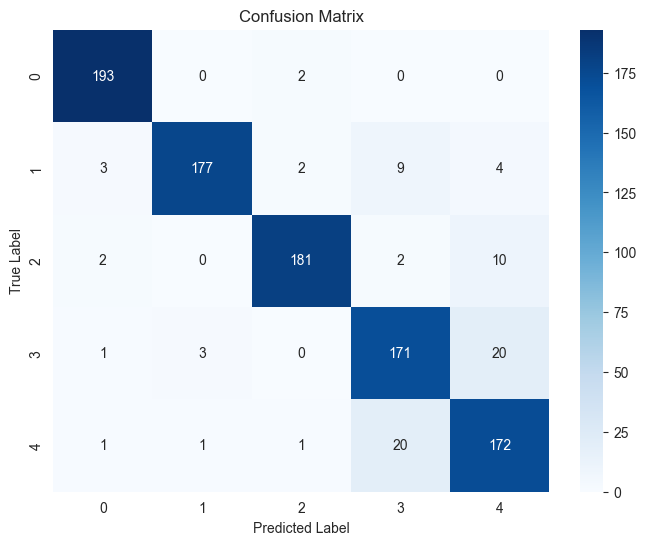

In [6]:
H_CM = run(subject='Byeongchan', Train_session=[0,1,2,4], Test_session=[3])
H.append(H_CM)

(34475, 4, 14, 1) (34475,)
(8625, 4, 14, 1) (8625,)
Start Training (total epochs: 100)...
Maximum training accuracy : 89.27%
Maximum validation accuracy : 87.25%


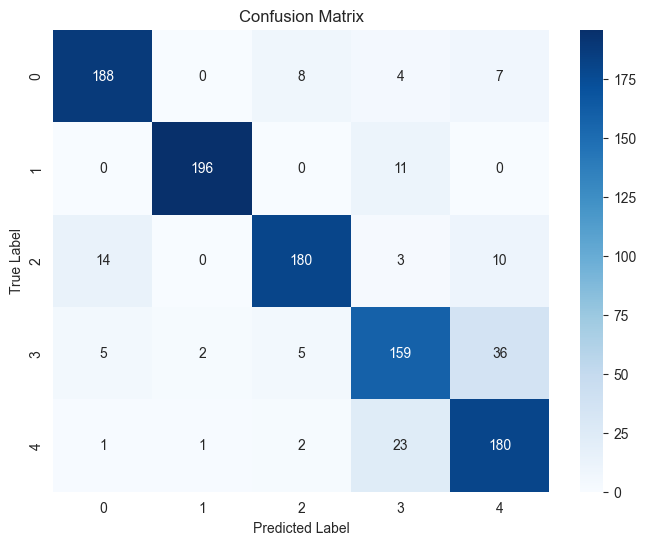

In [7]:
H_CM = run(subject='Byeongchan', Train_session=[0,1,3,4], Test_session=[2])
H.append(H_CM)

(34484, 4, 14, 1) (34484,)
(8616, 4, 14, 1) (8616,)
Start Training (total epochs: 100)...
Maximum training accuracy : 91.16%
Maximum validation accuracy : 90.71%


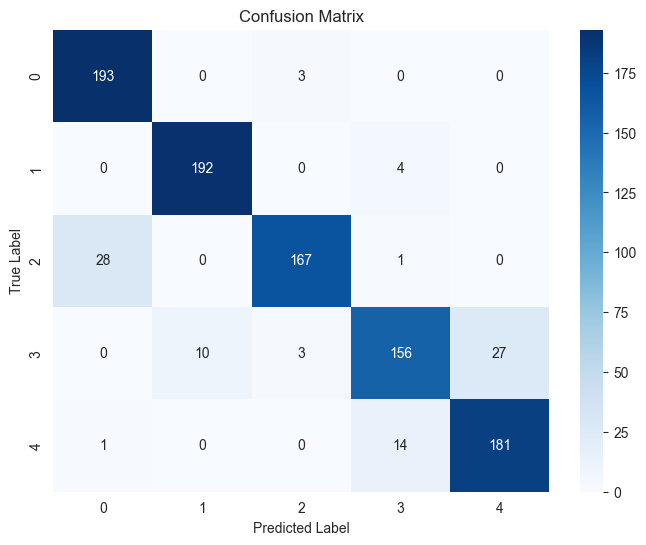

In [8]:
H_CM = run(subject='Byeongchan', Train_session=[0,2,3,4], Test_session=[1])
H.append(H_CM)

(34479, 4, 14, 1) (34479,)
(8621, 4, 14, 1) (8621,)
Start Training (total epochs: 100)...
Maximum training accuracy : 90.36%
Maximum validation accuracy : 88.38%


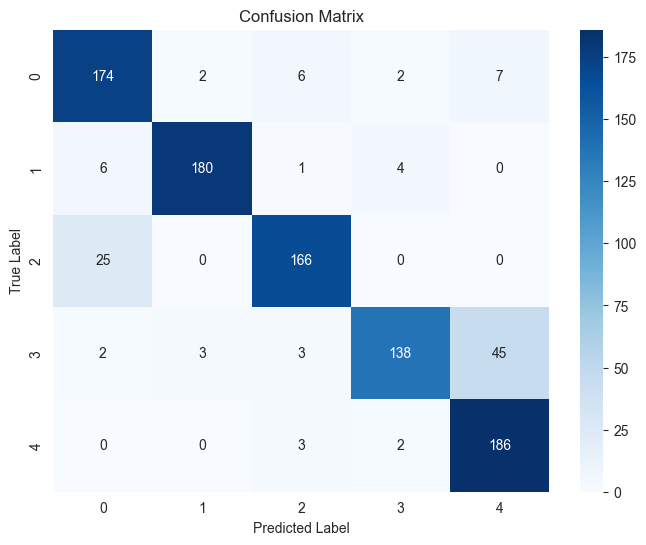

In [9]:
H_CM = run(subject='Byeongchan', Train_session=[1,2,3,4], Test_session=[0])
H.append(H_CM)

In [10]:
np.mean(H, axis=0)

array([[184.6,   0.4,   6.2,   1.4,   3.2],
       [  1.8, 184.2,   0.8,   7.6,   1.4],
       [ 14.8,   0. , 172. ,   3.6,   5.4],
       [  1.6,   3.6,   2.2, 160.4,  28. ],
       [  0.6,   0.4,   1.2,  17.2, 176.4]])

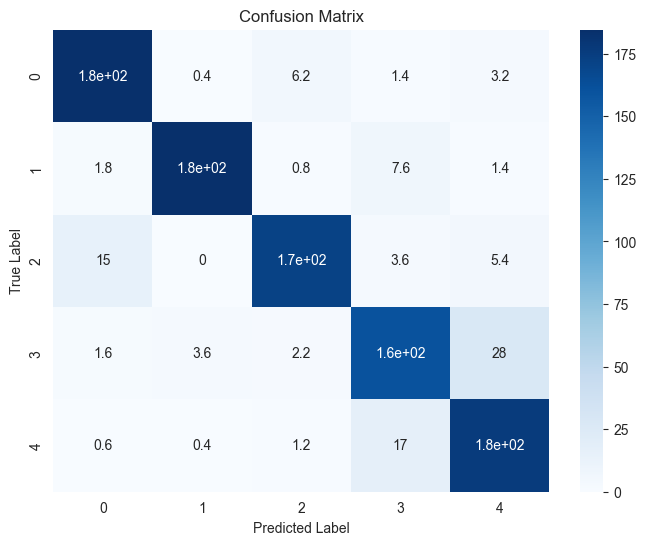

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(np.mean(H, axis=0), annot=True, cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [12]:
pd.DataFrame(np.mean(H, axis=0)).to_csv('./subject_BY_cross_validation_result_sENG.csv', index=False)

# Conclusion

sENG - 성능 잘나옴: 2D CNN 썼을때 (모든 feature 사용시) 약 77~91% in intersession

내일 병찬이랑 민정이 데이터 collection해서 실험돌리기

# Analysis - gesture 별로만 비교 해야할듯
- collection 부위도 다르고 amputee라서 애매함
- 근데 제스쳐 자체는 같았으니 feature로 해도될듯